# Library and Data Imports and Standardization

In [1]:
# Make the imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import sklearn as sk

# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Import ordinal encoder
from sklearn.preprocessing import OrdinalEncoder

# Import Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, make_scorer, r2_score, root_mean_squared_error

# Import train test split
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn import svm
from sklearn.kernel_approximation import RBFSampler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score
from pprint import pprint

# Import Random Forest Regressor and Classifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier

# Import time
import time

# Import Randomized Search CV
from sklearn.model_selection import RandomizedSearchCV

# Import confusion matrix
from sklearn.metrics import confusion_matrix

# Import kfold
from sklearn.model_selection import KFold

# Import cross val score
from sklearn.model_selection import cross_val_score

# Import math
import math

# Import log2
from math import log2

# Import classification report
from sklearn.metrics import classification_report

np.random.seed(42)

# Import SMOTE
from imblearn.over_sampling import SMOTE

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
path = '/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/data/'
# path = 'data/'
convabuse_filename = 'convabuse_imbalanced.csv'
dghs_filename = 'dynamically_generated_hate_speech_dataset_imbalanced.csv'
oaa_filename = 'online_abusive_attacks_class_imbalanced.csv'
us2020hs_filename = 'us_elections_2020_hate_speech_imbalanced.csv'
mlma_hate_speech_filename = 'MLMA_hate_speech_imbalanced.csv'

In [3]:
# Import the datasets
convabuse = pd.read_csv(f'{path}{convabuse_filename}')
dynamically_generated_hate_speech = pd.read_csv(f'{path}{dghs_filename}')
online_abusive_attacks = pd.read_csv(f'{path}{oaa_filename}')
us_elections_2020_hate_speech = pd.read_csv(f'{path}{us2020hs_filename}')
mlma_hate_speech = pd.read_csv(f'{path}{mlma_hate_speech_filename}')
mlma_hate_speech_sample = mlma_hate_speech.sample(frac=0.3, random_state=42)

In [4]:
convabuse.head()

,annotator_id,bot,generalised,individual,system,explicit,implicit,abuse_level,target_groups
0,7,0,0,0,0,0,0,0,0
1,7,0,0,0,0,0,0,1,0
2,7,0,0,0,0,0,0,0,0
3,7,1,0,0,0,0,0,0,0
4,7,0,0,0,0,0,0,0,0


In [5]:
convabuse_X = convabuse.drop(columns=["abuse_level", "individual", "generalised", "implicit"], axis=1)
convabuse_y = convabuse["abuse_level"]

In [6]:
dynamically_generated_hate_speech.head()

,label,type,annotator,target_groups,original
0,1.0,0,3,0,1
1,1.0,0,3,0,1
2,1.0,0,18,0,1
3,1.0,0,16,0,1
4,1.0,0,7,0,1


In [7]:
dghs_X = dynamically_generated_hate_speech.drop("label", axis=1)
dghs_y = dynamically_generated_hate_speech["label"]

In [8]:
online_abusive_attacks.head()

,Toxic parent tweets,Toxic replies,Toxic Level
0,0.0,0.0,0
1,67.0,13.0,2
2,28.0,45.0,2
3,47.0,49.0,2
4,97.0,7.0,3


In [9]:
oaa_X = online_abusive_attacks.drop("Toxic Level", axis=1)
oaa_y = online_abusive_attacks["Toxic Level"]

In [10]:
us_elections_2020_hate_speech.head()

,Trump,Biden,West,HOF
0,1,0,1,0
1,1,0,1,0
2,-1,0,1,0
3,0,0,1,0
4,0,1,1,0


In [11]:
us2020hs_X = us_elections_2020_hate_speech.drop(columns=["HOF", "West"], axis=1)
us2020hs_y = us_elections_2020_hate_speech["HOF"]

In [12]:
mlma_hate_speech.head()

,implicit,explicit,target_groups,annotator_sentiment,abuse_level
0,1,0,1,2,2
1,1,0,0,6,1
2,1,0,0,0,1
3,0,1,1,0,1
4,1,0,1,0,1


In [13]:
mlma_hate_speech_X = mlma_hate_speech.drop("target_groups", axis=1)
mlma_hate_speech_y = mlma_hate_speech["target_groups"]
mlma_hate_speech_X_sample = mlma_hate_speech_sample.drop("target_groups", axis=1)
mlma_hate_speech_y_sample = mlma_hate_speech_sample["target_groups"]

In [14]:
# Implement KFold
convabuse_kf = KFold(n_splits=5, shuffle=True, random_state=42)
dghs_kf = KFold(n_splits=5, shuffle=True, random_state=42)
oaa_kf = KFold(n_splits=5, shuffle=True, random_state=42)
us2020hs_kf = KFold(n_splits=5, shuffle=True, random_state=42)
mlma_hate_speech_kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Linear Modeling

In [15]:
# Get only the numeric features for each dataset
convabuse_X_numeric = convabuse_X.select_dtypes(include=np.number)
dghs_X_numeric = dghs_X.select_dtypes(include=np.number)
oaa_X_numeric = oaa_X.select_dtypes(include=np.number)
us2020hs_X_numeric = us2020hs_X.select_dtypes(include=np.number)
mlma_hate_speech_X_numeric = mlma_hate_speech_X.select_dtypes(include=np.number)
mlma_hate_speech_X_numeric_sample = mlma_hate_speech_X_sample.select_dtypes(include=np.number)

In [16]:
# Use standard scaler on the Convabuse X data
convabuse_scaler = StandardScaler()
convabuse_X_scaled = convabuse_scaler.fit_transform(convabuse_X_numeric)
convabuse_X_scaled = pd.DataFrame(convabuse_X_scaled, columns=convabuse_X_numeric.columns)

In [17]:
# Use standard scaler on the Dynamically Generated Hate Speech X data
dghs_scaler = StandardScaler()
dghs_X_scaled = dghs_scaler.fit_transform(dghs_X_numeric)
dghs_X_scaled = pd.DataFrame(dghs_X_scaled, columns=dghs_X_numeric.columns)

In [18]:
# Use standard scaler on the Online Abusive Attacks X data
oaa_scaler = StandardScaler()
oaa_X_scaled = oaa_scaler.fit_transform(oaa_X_numeric)
oaa_X_scaled = pd.DataFrame(oaa_X_scaled, columns=oaa_X_numeric.columns)

In [19]:
# Use standard scaler on the US elections 2020 hate speech X data
us2020hs_scaler = StandardScaler()
us2020hs_X_scaled = us2020hs_scaler.fit_transform(us2020hs_X_numeric)
us2020hs_X_scaled = pd.DataFrame(us2020hs_X_scaled, columns=us2020hs_X_numeric.columns)

In [20]:
# Use standard scaler on the MLMA hate speech X data
mlma_hate_speech_scaler = StandardScaler()
mlma_hate_speech_X_scaled = mlma_hate_speech_scaler.fit_transform(mlma_hate_speech_X_numeric)
mlma_hate_speech_X_scaled = pd.DataFrame(mlma_hate_speech_X_scaled, columns=mlma_hate_speech_X_numeric.columns)

In [21]:
# Use standard scaler on the MLMA hate speech X sample data
mlma_hate_speech_sample_scaler = StandardScaler()
mlma_hate_speech_X_sample_scaled = mlma_hate_speech_sample_scaler.fit_transform(mlma_hate_speech_X_numeric_sample)
mlma_hate_speech_X_sample_scaled = pd.DataFrame(mlma_hate_speech_X_sample_scaled, columns=mlma_hate_speech_X_numeric_sample.columns)

In [22]:
# Implement SMOTE to each dataset
smote = SMOTE(random_state=42)

convabuse_X_resampled, convabuse_y_resampled = smote.fit_resample(convabuse_X_scaled, convabuse_y)
dghs_X_resampled, dghs_y_resampled = smote.fit_resample(dghs_X_scaled, dghs_y)
oaa_X_resampled, oaa_y_resampled = smote.fit_resample(oaa_X_scaled, oaa_y)
us2020hs_X_resampled, us2020hs_y_resampled = smote.fit_resample(us2020hs_X_scaled, us2020hs_y)
mlma_hate_speech_X_resampled, mlma_hate_speech_y_resampled = smote.fit_resample(mlma_hate_speech_X_scaled, mlma_hate_speech_y)
mlma_hate_speech_X_sample_resampled, mlma_hate_speech_y_sample_resampled = smote.fit_resample(mlma_hate_speech_X_sample_scaled, mlma_hate_speech_y_sample)

In [23]:
# Train test split for each dataset
convabuse_X_train, convabuse_X_test, convabuse_y_train, convabuse_y_test = train_test_split(convabuse_X_resampled, convabuse_y_resampled, test_size=0.2, random_state=42, stratify=convabuse_y_resampled)
dghs_X_train, dghs_X_test, dghs_y_train, dghs_y_test = train_test_split(dghs_X_resampled, dghs_y_resampled, test_size=0.2, random_state=42, stratify=dghs_y_resampled)
oaa_X_train, oaa_X_test, oaa_y_train, oaa_y_test = train_test_split(oaa_X_resampled, oaa_y_resampled, test_size=0.2, random_state=42, stratify=oaa_y_resampled)
us2020hs_X_train, us2020hs_X_test, us2020hs_y_train, us2020hs_y_test = train_test_split(us2020hs_X_resampled, us2020hs_y_resampled, test_size=0.2, random_state=42, stratify=us2020hs_y_resampled)
mlma_hate_speech_X_train, mlma_hate_speech_X_test, mlma_hate_speech_y_train, mlma_hate_speech_y_test = train_test_split(mlma_hate_speech_X_resampled, mlma_hate_speech_y_resampled, test_size=0.2, random_state=42, stratify=mlma_hate_speech_y_resampled)
mlma_hate_speech_X_train_sample, mlma_hate_speech_X_test_sample, mlma_hate_speech_y_train_sample, mlma_hate_speech_y_test_sample = train_test_split(mlma_hate_speech_X_sample_resampled, mlma_hate_speech_y_sample_resampled, test_size=0.2, random_state=42, stratify=mlma_hate_speech_y_sample_resampled)

In [24]:
for columns in [convabuse_X_numeric.columns, dghs_X_numeric.columns, oaa_X_numeric.columns, us2020hs_X_numeric.columns, mlma_hate_speech_X_numeric.columns]:
  print(columns)

Index(['annotator_id', 'bot', 'system', 'explicit', 'target_groups'], dtype='object')
Index(['type', 'annotator', 'target_groups', 'original'], dtype='object')
Index(['Toxic parent tweets', 'Toxic replies'], dtype='object')
Index(['Trump', 'Biden'], dtype='object')
Index(['implicit', 'explicit', 'annotator_sentiment', 'abuse_level'], dtype='object')


In [25]:
# Train test split for each dataset
convabuse_X_train, convabuse_X_test, convabuse_y_train, convabuse_y_test = train_test_split(convabuse_X_scaled, convabuse_y, test_size=0.2, random_state=42)
dghs_X_train, dghs_X_test, dghs_y_train, dghs_y_test = train_test_split(dghs_X_scaled, dghs_y, test_size=0.2, random_state=42)
oaa_X_train, oaa_X_test, oaa_y_train, oaa_y_test = train_test_split(oaa_X_scaled, oaa_y, test_size=0.2, random_state=42)
us2020hs_X_train, us2020hs_X_test, us2020hs_y_train, us2020hs_y_test = train_test_split(us2020hs_X_scaled, us2020hs_y, test_size=0.2, random_state=42)
mlma_hate_speech_X_train, mlma_hate_speech_X_test, mlma_hate_speech_y_train, mlma_hate_speech_y_test = train_test_split(mlma_hate_speech_X_scaled, mlma_hate_speech_y, test_size=0.2, random_state=42)
mlma_hate_speech_X_train_sample, mlma_hate_speech_X_test_sample, mlma_hate_speech_y_train_sample, mlma_hate_speech_y_test_sample = train_test_split(mlma_hate_speech_X_sample_scaled, mlma_hate_speech_y_sample, test_size=0.2, random_state=42)

In [26]:
# Get the length of each dataset
convabuse_length = len(convabuse_X_train)
dghs_length = len(dghs_X_train)
oaa_length = len(oaa_X_train)
us2020hs_length = len(us2020hs_X_train)
mlma_hate_speech_length = len(mlma_hate_speech_X_train)
mlma_hate_speech_sample_length = len(mlma_hate_speech_X_train_sample)

In [27]:
convabuse_log2 = math.ceil(log2(convabuse_length))
convabuse_1_percent = math.ceil(convabuse_length * 0.01)
convabuse_length, convabuse_log2, convabuse_1_percent

(10061, 14, 101)

In [28]:
dghs_log2 = math.ceil(log2(dghs_length))
dghs_1_percent = math.ceil(dghs_length * 0.01)
dghs_length, dghs_log2, dghs_1_percent

(32749, 15, 328)

In [29]:
oaa_log2 = math.ceil(log2(oaa_length))
oaa_1_percent = math.ceil(oaa_length * 0.01)
oaa_length, oaa_log2, oaa_1_percent

(1850, 11, 19)

In [30]:
us2020hs_log2 = math.ceil(log2(us2020hs_length))
us2020hs_1_percent = math.ceil(us2020hs_length * 0.01)
us2020hs_length, us2020hs_log2, us2020hs_1_percent

(2392, 12, 24)

In [31]:
mlma_hate_speech_log2 = math.ceil(log2(mlma_hate_speech_length))
mlma_hate_speech_1_percent = math.ceil(mlma_hate_speech_length * 0.01)
mlma_hate_speech_length, mlma_hate_speech_log2, mlma_hate_speech_1_percent

(14928, 14, 150)

In [32]:
mlma_hate_speech_sample_log2 = math.ceil(log2(mlma_hate_speech_sample_length))
mlma_hate_speech_sample_1_percent = math.ceil(mlma_hate_speech_sample_length * 0.01)
mlma_hate_speech_sample_length, mlma_hate_speech_sample_log2, mlma_hate_speech_sample_1_percent

(4478, 13, 45)

In [33]:
rf_classification_results_list = []

In [34]:
balance = "SMOTE"

## Convabuse Decision Tree

In [35]:
convabuse_y_test.value_counts()

,count
abuse_level,
0,1999
3,177
2,159
1,130
4,51


In [36]:
convabuse_1_percent

101

In [37]:
# Random Forest Classifier pipeline for Convabuse dataset
convabuse_rf_pipeline = Pipeline([
    ('rf_classifier', RandomForestClassifier(random_state=42))
])

# Set the parameters for Randomized Search for Random Forest Classifier on the Convabuse dataset
convabuse_rf_param_grid = {
    'rf_classifier__n_estimators': range(1000),
    'rf_classifier__max_depth': range(1, convabuse_log2),
    'rf_classifier__min_samples_split': [convabuse_1_percent * i for i in range(2, 6)],
    'rf_classifier__min_samples_leaf': [convabuse_1_percent * i for i in range(1, 6)],
    'rf_classifier__criterion': ['gini']
}

In [38]:
start_time = time.time()
convabuse_class_scorer = make_scorer(accuracy_score, greater_is_better=True)

convabuse_rf_random_search = RandomizedSearchCV(convabuse_rf_pipeline,
                                                   param_distributions=convabuse_rf_param_grid,
                                                   n_iter=10,
                                                   cv=convabuse_kf,
                                                   scoring=convabuse_class_scorer,
                                                   random_state=42)
convabuse_rf_random_search.fit(convabuse_X_train, convabuse_y_train)
end_time = time.time()
print("Best parameters for Convabuse Random Forest Classifier:", convabuse_rf_random_search.best_params_)
print("Best score for Convabuse Random Forest Classifier:", convabuse_rf_random_search.best_score_)
print("Time taken for Convabuse Random Forest Classifier Randomized Search:", end_time - start_time)

Best parameters for Convabuse Random Forest Classifier: {'rf_classifier__n_estimators': 958, 'rf_classifier__min_samples_split': 303, 'rf_classifier__min_samples_leaf': 101, 'rf_classifier__max_depth': 7, 'rf_classifier__criterion': 'gini'}
Best score for Convabuse Random Forest Classifier: 0.8881819366957717
Time taken for Convabuse Random Forest Classifier Randomized Search: 108.38410830497742


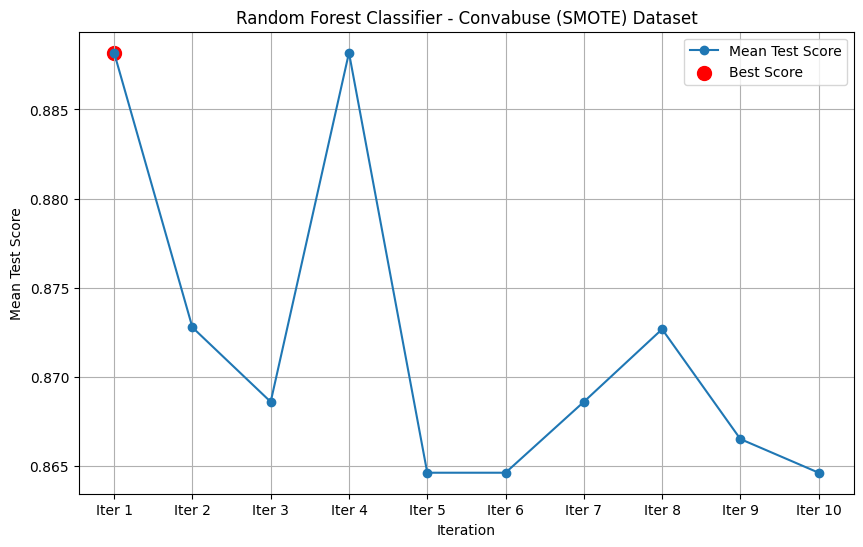

In [39]:
# Plot the accuracy scores for the Random Forest Classifier on the US Accidents dataset for all iterations
plt.figure(figsize=(10, 6))
plt.plot(convabuse_rf_random_search.cv_results_['mean_test_score'], marker='o', label='Mean Test Score')

# Plot the best score as a red x
convabuse_rf_best_score_index = np.argmax(convabuse_rf_random_search.cv_results_['mean_test_score'])
plt.scatter(convabuse_rf_best_score_index, convabuse_rf_random_search.cv_results_['mean_test_score'][convabuse_rf_best_score_index], color='red', s=100, label='Best Score')

plt.title(f'Random Forest Classifier - Convabuse ({balance}) Dataset')
plt.xlabel('Iteration')
plt.ylabel('Mean Test Score')
plt.xticks(range(len(convabuse_rf_random_search.cv_results_['mean_test_score'])),
           [f"Iter {i+1}" for i in range(len(convabuse_rf_random_search.cv_results_['mean_test_score']))])
plt.legend()
plt.grid()
plt.show()

In [40]:
# Predict on the test set
convabuse_rf_y_pred = convabuse_rf_random_search.predict(convabuse_X_test)

In [41]:
# Evaluate the model
convabuse_rf_accuracy = accuracy_score(convabuse_y_test, convabuse_rf_y_pred)
convabuse_rf_f1 = f1_score(convabuse_y_test, convabuse_rf_y_pred, average='weighted')

print("Convabuse Random Forest Classifier:")
print(f"Best Parameters: {convabuse_rf_random_search.best_params_}")
print(f"Accuracy: {convabuse_rf_accuracy:.4f}")
print(f"F1 Score: {convabuse_rf_f1:.4f}")

Convabuse Random Forest Classifier:
Best Parameters: {'rf_classifier__n_estimators': 958, 'rf_classifier__min_samples_split': 303, 'rf_classifier__min_samples_leaf': 101, 'rf_classifier__max_depth': 7, 'rf_classifier__criterion': 'gini'}
Accuracy: 0.8835
F1 Score: 0.8493


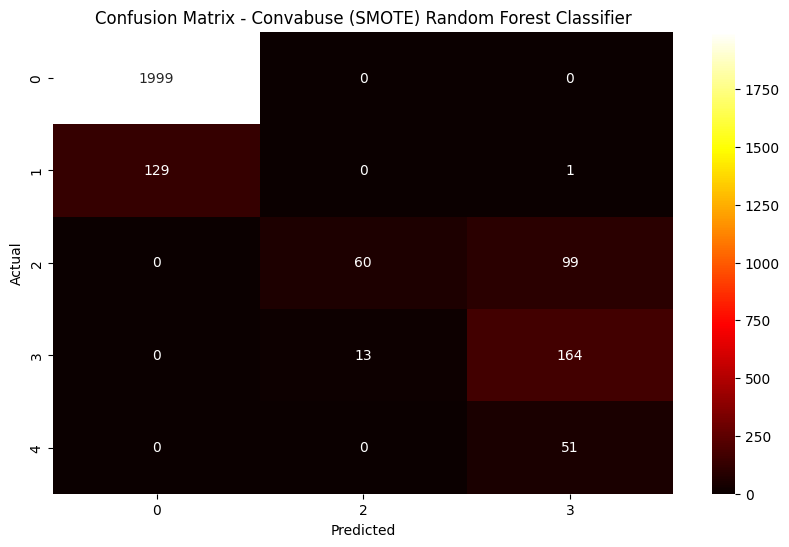

In [42]:
# Plot the confusion matrix using seaborn
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(convabuse_y_test, convabuse_rf_y_pred, rownames=['Actual'], colnames=['Predicted']), annot=True, fmt='d', cmap='hot')
plt.title(f'Confusion Matrix - Convabuse ({balance}) Random Forest Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [43]:
# Generate a classification report for the Random Forest Classifier on the Convabuse dataset
convabuse_rf_report = classification_report(convabuse_y_test, convabuse_rf_y_pred)
print("Classification Report for Convabuse Random Forest Classifier:")
print(convabuse_rf_report)

Classification Report for Convabuse Random Forest Classifier:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      1999
           1       0.00      0.00      0.00       130
           2       0.82      0.38      0.52       159
           3       0.52      0.93      0.67       177
           4       0.00      0.00      0.00        51

    accuracy                           0.88      2516
   macro avg       0.46      0.46      0.43      2516
weighted avg       0.83      0.88      0.85      2516



,feature,importance
2,system,0.523268
3,explicit,0.295282
4,target_groups,0.134180
0,annotator_id,0.031320
1,bot,0.015949


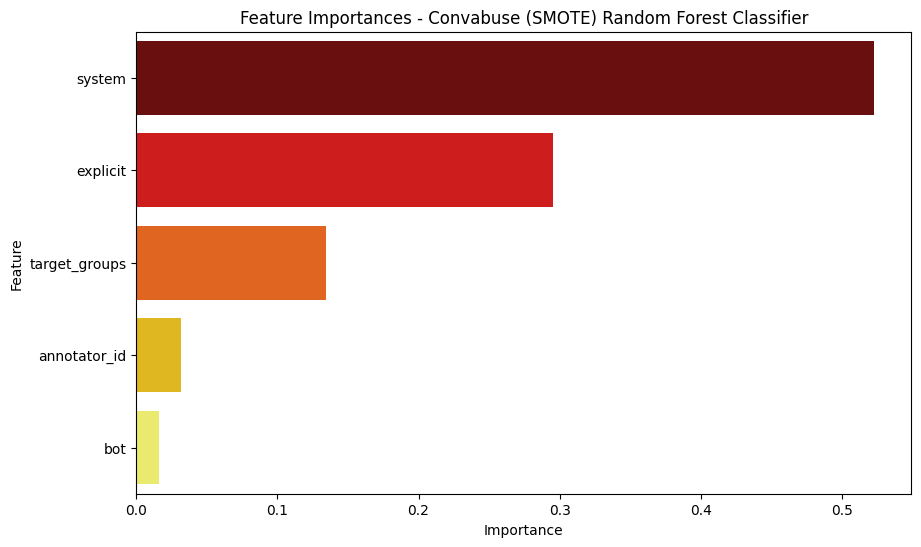

In [44]:
# Determine the feature importances
convabuse_rf_feature_importances = convabuse_rf_random_search.best_estimator_.named_steps['rf_classifier'].feature_importances_
convabuse_rf_feature_importances_df = pd.DataFrame({'feature': convabuse_X_train.columns, 'importance': convabuse_rf_feature_importances}).sort_values('importance', ascending=False)
display(convabuse_rf_feature_importances_df)

# Create a dictionary
convabuse_rf_feature_importances_dict = convabuse_rf_feature_importances_df.set_index('feature')['importance'].to_dict()

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=convabuse_rf_feature_importances_df, palette='hot')
plt.title(f'Feature Importances - Convabuse ({balance}) Random Forest Classifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [45]:
# Append details to the results list
rf_classification_results_list.append((
    "Random Forest",
    "Convabuse",
    "NA",
    "NA",
    convabuse_rf_accuracy,
    convabuse_rf_f1,
    0.0,
    convabuse_rf_random_search.best_params_,
    convabuse_rf_feature_importances_dict
))

## Dynamically Generated Hate Speech Decision Tree

In [46]:
dghs_y_test.value_counts()

,count
label,
1.0,4429
0.0,3759


In [47]:
# Random Forest Classifier pipeline for DGHS dataset
dghs_rf_pipeline = Pipeline([
    ('rf_classifier', RandomForestClassifier(random_state=42))
])

# Set the parameters for Randomized Search for Random Forest Classifier on the DGHS dataset
dghs_rf_param_grid = {
    'rf_classifier__n_estimators': range(1000),
    'rf_classifier__max_depth': range(1, dghs_log2),
    'rf_classifier__min_samples_split': [dghs_1_percent * i for i in range(2, 6)],
    'rf_classifier__min_samples_leaf': [dghs_1_percent * i for i in range(1, 6)],
    'rf_classifier__criterion': ['gini', 'entropy']
}

In [48]:
start_time = time.time()
dghs_class_scorer = make_scorer(accuracy_score, greater_is_better=True)

dghs_rf_random_search = RandomizedSearchCV(dghs_rf_pipeline,
                                           param_distributions=dghs_rf_param_grid,
                                           n_iter=10,
                                           cv=dghs_kf,
                                           scoring=dghs_class_scorer,
                                           random_state=42)
dghs_rf_random_search.fit(dghs_X_train, dghs_y_train)
end_time = time.time()
print("Best parameters for Dynamically Generated Hate Speech Random Forest Classifier:", dghs_rf_random_search.best_params_)
print("Best score for Dynamically Generated Hate Speech Random Forest Classifier:", dghs_rf_random_search.best_score_)
print("Time taken for Dynamically Generated Hate Speech Random Forest Classifier Randomized Search:", end_time - start_time)

Best parameters for Dynamically Generated Hate Speech Random Forest Classifier: {'rf_classifier__n_estimators': 958, 'rf_classifier__min_samples_split': 984, 'rf_classifier__min_samples_leaf': 328, 'rf_classifier__max_depth': 7, 'rf_classifier__criterion': 'gini'}
Best score for Dynamically Generated Hate Speech Random Forest Classifier: 0.8419798698944773
Time taken for Dynamically Generated Hate Speech Random Forest Classifier Randomized Search: 152.74693036079407


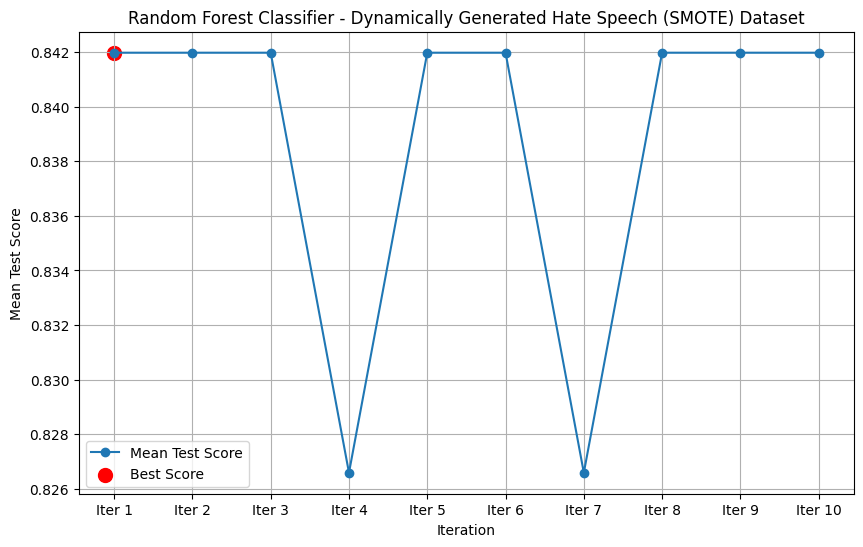

In [49]:
# Plot the accuracy scores for the Random Forest Classifier on the US Accidents dataset for all iterations
plt.figure(figsize=(10, 6))
plt.plot(dghs_rf_random_search.cv_results_['mean_test_score'], marker='o', label='Mean Test Score')

# Plot the best score as a red x
dghs_rf_best_score_index = np.argmax(dghs_rf_random_search.cv_results_['mean_test_score'])
plt.scatter(dghs_rf_best_score_index, dghs_rf_random_search.cv_results_['mean_test_score'][dghs_rf_best_score_index], color='red', s=100, label='Best Score')

plt.title(f'Random Forest Classifier - Dynamically Generated Hate Speech ({balance}) Dataset')
plt.xlabel('Iteration')
plt.ylabel('Mean Test Score')
plt.xticks(range(len(dghs_rf_random_search.cv_results_['mean_test_score'])),
           [f"Iter {i+1}" for i in range(len(dghs_rf_random_search.cv_results_['mean_test_score']))])
plt.legend()
plt.grid()
plt.show()

In [50]:
# Predict on the test set
dghs_rf_y_pred = dghs_rf_random_search.predict(dghs_X_test)

In [51]:
# Evaluate the model
dghs_rf_accuracy = accuracy_score(dghs_y_test, dghs_rf_y_pred)
dghs_rf_f1 = f1_score(dghs_y_test, dghs_rf_y_pred, average='weighted')

print("Dynamically Generated Hate Speech Random Forest Classifier:")
print(f"Best Parameters: {dghs_rf_random_search.best_params_}")
print(f"Accuracy: {dghs_rf_accuracy:.4f}")
print(f"F1 Score: {dghs_rf_f1:.4f}")

Dynamically Generated Hate Speech Random Forest Classifier:
Best Parameters: {'rf_classifier__n_estimators': 958, 'rf_classifier__min_samples_split': 984, 'rf_classifier__min_samples_leaf': 328, 'rf_classifier__max_depth': 7, 'rf_classifier__criterion': 'gini'}
Accuracy: 0.8405
F1 Score: 0.8402


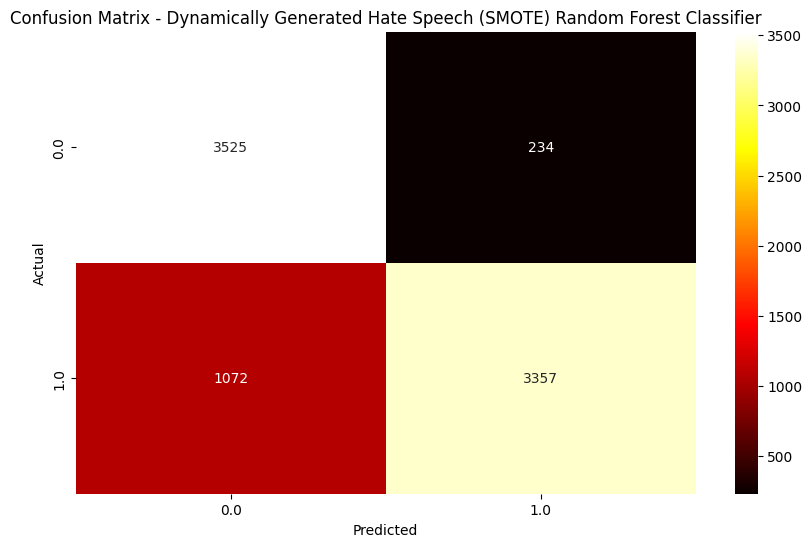

In [52]:
# Plot the confusion matrix using seaborn
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(dghs_y_test, dghs_rf_y_pred, rownames=['Actual'], colnames=['Predicted']), annot=True, fmt='d', cmap='hot')
plt.title(f'Confusion Matrix - Dynamically Generated Hate Speech ({balance}) Random Forest Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [53]:
# Generate a classification report for the Random Forest Classifier on the Dynamically Generated Hate Speech dataset
dghs_rf_report = classification_report(dghs_y_test, dghs_rf_y_pred)
print("Classification Report for Dynamically Generated Hate Speech Random Forest Classifier:")
print(dghs_rf_report)

Classification Report for Dynamically Generated Hate Speech Random Forest Classifier:
              precision    recall  f1-score   support

         0.0       0.77      0.94      0.84      3759
         1.0       0.93      0.76      0.84      4429

    accuracy                           0.84      8188
   macro avg       0.85      0.85      0.84      8188
weighted avg       0.86      0.84      0.84      8188



,feature,importance
0,type,0.658333
2,target_groups,0.185154
3,original,0.103078
1,annotator,0.053436


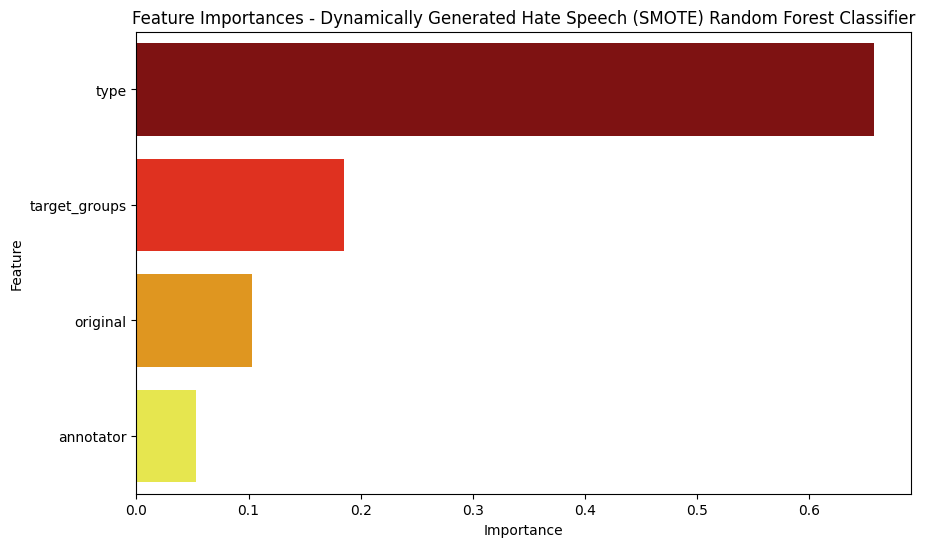

In [54]:
# Determine the feature importances
dghs_rf_feature_importances = dghs_rf_random_search.best_estimator_.named_steps['rf_classifier'].feature_importances_
dghs_rf_feature_importances_df = pd.DataFrame({'feature': dghs_X_train.columns, 'importance': dghs_rf_feature_importances}).sort_values('importance', ascending=False)
display(dghs_rf_feature_importances_df)

# Create a dictionary
dghs_rf_feature_importances_dict = dghs_rf_feature_importances_df.set_index('feature')['importance'].to_dict()

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=dghs_rf_feature_importances_df, palette='hot')
plt.title(f'Feature Importances - Dynamically Generated Hate Speech ({balance}) Random Forest Classifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [55]:
# Append details to the results list
rf_classification_results_list.append((
    "Random Forest",
    "Dynamically Generated Hate Speech",
    "NA",
    "NA",
    dghs_rf_accuracy,
    dghs_rf_f1,
    0.0,
    dghs_rf_random_search.best_params_,
    dghs_rf_feature_importances_dict
))

## Online Abusive Attacks Random Forest

In [56]:
oaa_y_test.value_counts()

,count
Toxic Level,
0,221
1,177
2,33
4,17
3,15


In [57]:
# Random Forest Classifier pipeline for OAA dataset
oaa_rf_pipeline = Pipeline([
    ('rf_classifier', RandomForestClassifier(random_state=42))
])

# Set the parameters for Randomized Search for Random Forest Classifier on the OAA dataset
oaa_rf_param_grid = {
    'rf_classifier__n_estimators': range(1000),
    'rf_classifier__max_depth': range(1, oaa_log2),
    'rf_classifier__min_samples_split': [oaa_1_percent * i for i in range(2, 6)],
    'rf_classifier__min_samples_leaf': [oaa_1_percent * i for i in range(1, 6)],
    'rf_classifier__criterion': ['gini', 'entropy']
}

In [58]:
start_time = time.time()
oaa_class_scorer = make_scorer(accuracy_score, greater_is_better=True)

oaa_rf_random_search = RandomizedSearchCV(oaa_rf_pipeline,
                                           param_distributions=oaa_rf_param_grid,
                                           n_iter=10,
                                           cv=oaa_kf,
                                           scoring=oaa_class_scorer,
                                           random_state=42)
oaa_rf_random_search.fit(oaa_X_train, oaa_y_train)
end_time = time.time()
print("Best parameters for Online Abusive Attacks Random Forest Classifier:", oaa_rf_random_search.best_params_)
print("Best score for Online Abusive Attacks Random Forest Classifier:", oaa_rf_random_search.best_score_)
print("Time taken for Online Abusive Attacks Random Forest Classifier Randomized Search:", end_time - start_time)

Best parameters for Online Abusive Attacks Random Forest Classifier: {'rf_classifier__n_estimators': 958, 'rf_classifier__min_samples_split': 57, 'rf_classifier__min_samples_leaf': 19, 'rf_classifier__max_depth': 7, 'rf_classifier__criterion': 'gini'}
Best score for Online Abusive Attacks Random Forest Classifier: 0.9318918918918918
Time taken for Online Abusive Attacks Random Forest Classifier Randomized Search: 63.330138206481934


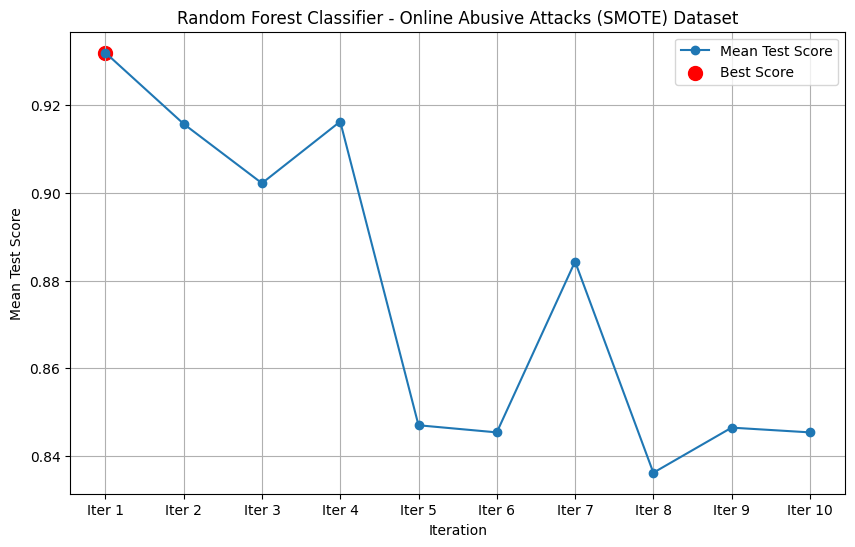

In [59]:
# Plot the accuracy scores for the Random Forest Classifier on the US Accidents dataset for all iterations
plt.figure(figsize=(10, 6))
plt.plot(oaa_rf_random_search.cv_results_['mean_test_score'], marker='o', label='Mean Test Score')

# Plot the best score as a red x
oaa_rf_best_score_index = np.argmax(oaa_rf_random_search.cv_results_['mean_test_score'])
plt.scatter(oaa_rf_best_score_index, oaa_rf_random_search.cv_results_['mean_test_score'][oaa_rf_best_score_index], color='red', s=100, label='Best Score')

plt.title(f'Random Forest Classifier - Online Abusive Attacks ({balance}) Dataset')
plt.xlabel('Iteration')
plt.ylabel('Mean Test Score')
plt.xticks(range(len(oaa_rf_random_search.cv_results_['mean_test_score'])),
           [f"Iter {i+1}" for i in range(len(oaa_rf_random_search.cv_results_['mean_test_score']))])
plt.legend()
plt.grid()
plt.show()

In [60]:
# Predict on the test set
oaa_rf_y_pred = oaa_rf_random_search.predict(oaa_X_test)

In [61]:
# Evaluate the model
oaa_rf_accuracy = accuracy_score(oaa_y_test, oaa_rf_y_pred)
oaa_rf_f1 = f1_score(oaa_y_test, oaa_rf_y_pred, average='weighted')

print("Online Abusive Attacks Random Forest Classifier:")
print(f"Best Parameters: {oaa_rf_random_search.best_params_}")
print(f"Accuracy: {oaa_rf_accuracy:.4f}")
print(f"F1 Score: {oaa_rf_f1:.4f}")

Online Abusive Attacks Random Forest Classifier:
Best Parameters: {'rf_classifier__n_estimators': 958, 'rf_classifier__min_samples_split': 57, 'rf_classifier__min_samples_leaf': 19, 'rf_classifier__max_depth': 7, 'rf_classifier__criterion': 'gini'}
Accuracy: 0.9698
F1 Score: 0.9682


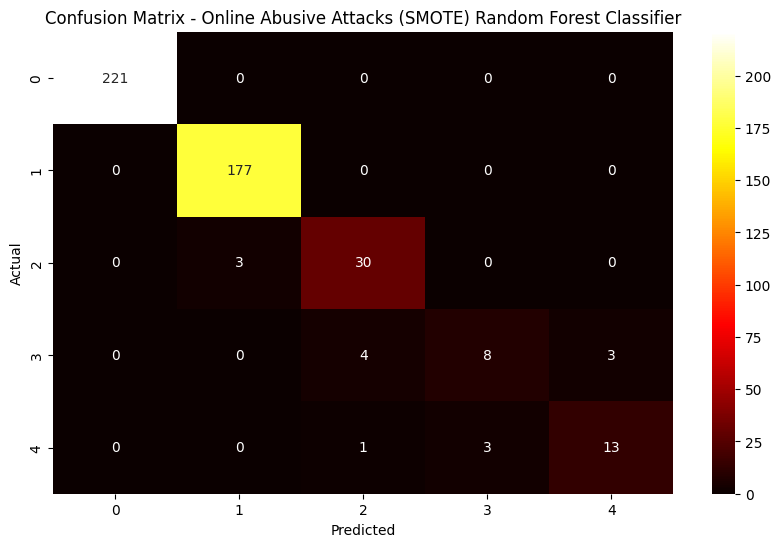

In [62]:
# Plot the confusion matrix using seaborn
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(oaa_y_test, oaa_rf_y_pred, rownames=['Actual'], colnames=['Predicted']), annot=True, fmt='d', cmap='hot')
plt.title(f'Confusion Matrix - Online Abusive Attacks ({balance}) Random Forest Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [63]:
# Generate a classification report for the Random Forest Classifier on the Online Abusive Attacks dataset
oaa_rf_report = classification_report(oaa_y_test, oaa_rf_y_pred)
print("Classification Report for Online Abusive Attacks Random Forest Classifier:")
print(oaa_rf_report)

Classification Report for Online Abusive Attacks Random Forest Classifier:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       221
           1       0.98      1.00      0.99       177
           2       0.86      0.91      0.88        33
           3       0.73      0.53      0.62        15
           4       0.81      0.76      0.79        17

    accuracy                           0.97       463
   macro avg       0.88      0.84      0.86       463
weighted avg       0.97      0.97      0.97       463



,feature,importance
0,Toxic parent tweets,0.81626
1,Toxic replies,0.18374


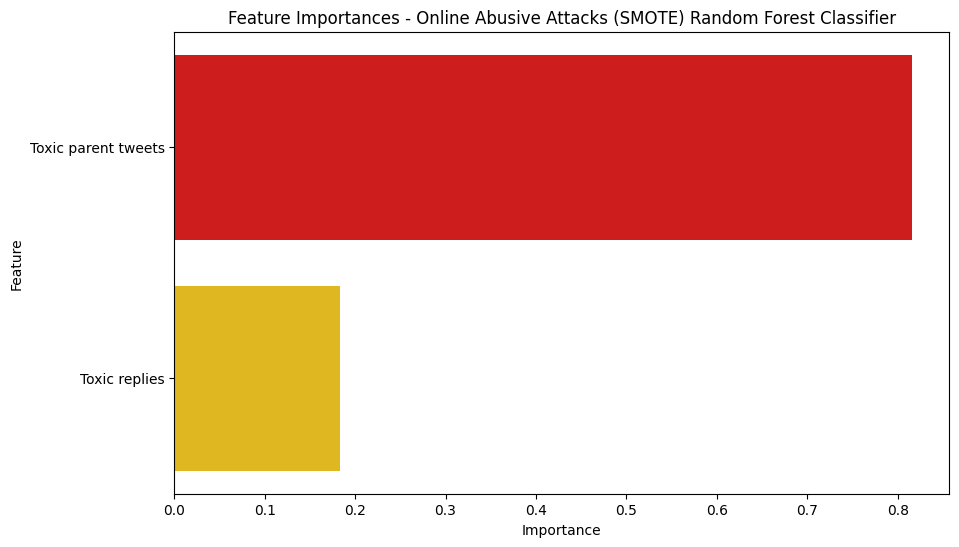

In [64]:
# Determine the feature importances
oaa_rf_feature_importances = oaa_rf_random_search.best_estimator_.named_steps['rf_classifier'].feature_importances_
oaa_rf_feature_importances_df = pd.DataFrame({'feature': oaa_X_train.columns, 'importance': oaa_rf_feature_importances}).sort_values('importance', ascending=False)
display(oaa_rf_feature_importances_df)

# Create a dictionary
oaa_rf_feature_importances_dict = oaa_rf_feature_importances_df.set_index('feature')['importance'].to_dict()

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=oaa_rf_feature_importances_df, palette='hot')
plt.title(f'Feature Importances - Online Abusive Attacks ({balance}) Random Forest Classifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [65]:
# Append details to the results list
rf_classification_results_list.append((
    "Random Forest",
    "Online Abusive Attacks",
    "NA",
    "NA",
    oaa_rf_accuracy,
    oaa_rf_f1,
    0.0,
    oaa_rf_random_search.best_params_,
    oaa_rf_feature_importances_dict
))

In [66]:
us2020hs_y_test.value_counts()

,count
HOF,
0,525
1,74


In [67]:
# Random Forest Classifier pipeline for us2020hs dataset
us2020hs_rf_pipeline = Pipeline([
    ('rf_classifier', RandomForestClassifier(random_state=42))
])

# Set the parameters for Randomized Search for Random Forest Classifier on the us2020hs dataset
us2020hs_rf_param_grid = {
    'rf_classifier__n_estimators': range(1000),
    'rf_classifier__max_depth': [us2020hs_log2],
    'rf_classifier__min_samples_split': [us2020hs_1_percent * i for i in range(2, 6)],
    'rf_classifier__min_samples_leaf': [us2020hs_1_percent * i for i in range(1, 6)],
    'rf_classifier__criterion': ['gini', 'entropy']
}

In [68]:
start_time = time.time()
us2020hs_class_scorer = make_scorer(accuracy_score, greater_is_better=True)

us2020hs_rf_random_search = RandomizedSearchCV(us2020hs_rf_pipeline,
                                                   param_distributions=us2020hs_rf_param_grid,
                                                   n_iter=10,
                                                   cv=us2020hs_kf,
                                                   scoring=us2020hs_class_scorer,
                                                   random_state=42)
us2020hs_rf_random_search.fit(us2020hs_X_train, us2020hs_y_train)
end_time = time.time()
print("Best parameters for US Elections 2020 Hate Speech Random Forest Classifier:", us2020hs_rf_random_search.best_params_)
print("Best score for US Elections 2020 Hate Speech Random Forest Classifier:", us2020hs_rf_random_search.best_score_)
print("Time taken for US Elections 2020 Hate Speech Random Forest Classifier Randomized Search:", end_time - start_time)

Best parameters for US Elections 2020 Hate Speech Random Forest Classifier: {'rf_classifier__n_estimators': 795, 'rf_classifier__min_samples_split': 120, 'rf_classifier__min_samples_leaf': 96, 'rf_classifier__max_depth': 12, 'rf_classifier__criterion': 'gini'}
Best score for US Elections 2020 Hate Speech Random Forest Classifier: 0.8837711061224132
Time taken for US Elections 2020 Hate Speech Random Forest Classifier Randomized Search: 47.494815826416016


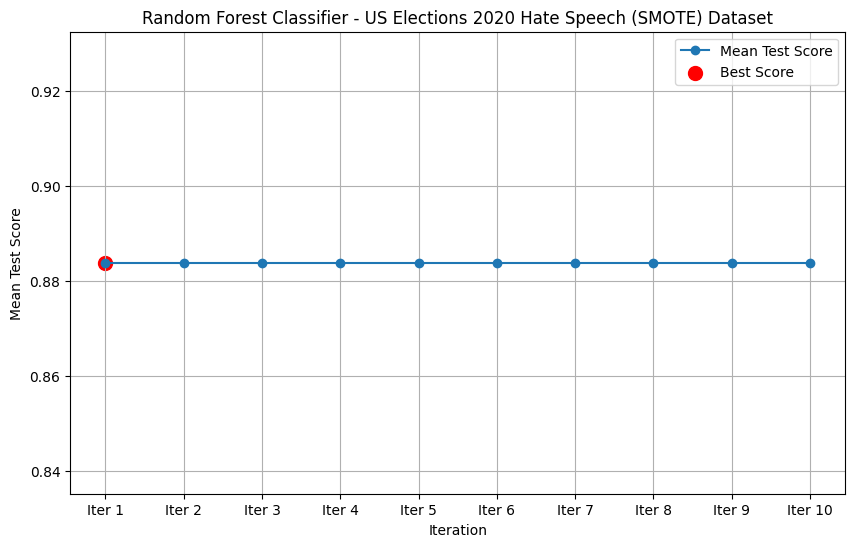

In [69]:
# Plot the accuracy scores for the Random Forest Classifier on the US Elections 2020 Hate Speech dataset for all iterations
plt.figure(figsize=(10, 6))
plt.plot(us2020hs_rf_random_search.cv_results_['mean_test_score'], marker='o', label='Mean Test Score')

# Plot the best score as a red x
us2020hs_rf_best_score_index = np.argmax(us2020hs_rf_random_search.cv_results_['mean_test_score'])
plt.scatter(us2020hs_rf_best_score_index, us2020hs_rf_random_search.cv_results_['mean_test_score'][us2020hs_rf_best_score_index], color='red', s=100, label='Best Score')

plt.title(f'Random Forest Classifier - US Elections 2020 Hate Speech ({balance}) Dataset')
plt.xlabel('Iteration')
plt.ylabel('Mean Test Score')
plt.xticks(range(len(us2020hs_rf_random_search.cv_results_['mean_test_score'])),
           [f"Iter {i+1}" for i in range(len(us2020hs_rf_random_search.cv_results_['mean_test_score']))])
plt.legend()
plt.grid()
plt.show()

In [70]:
# Predict on the test set
us2020hs_rf_y_pred = us2020hs_rf_random_search.predict(us2020hs_X_test)

In [71]:
# Evaluate the model
us2020hs_rf_accuracy = accuracy_score(us2020hs_y_test, us2020hs_rf_y_pred)
us2020hs_rf_f1 = f1_score(us2020hs_y_test, us2020hs_rf_y_pred, average='weighted')

print("US Elections 2020 Hate Speech Random Forest Classifier:")
print(f"Best Parameters: {us2020hs_rf_random_search.best_params_}")
print(f"Accuracy: {us2020hs_rf_accuracy:.4f}")
print(f"F1 Score: {us2020hs_rf_f1:.4f}")

US Elections 2020 Hate Speech Random Forest Classifier:
Best Parameters: {'rf_classifier__n_estimators': 795, 'rf_classifier__min_samples_split': 120, 'rf_classifier__min_samples_leaf': 96, 'rf_classifier__max_depth': 12, 'rf_classifier__criterion': 'gini'}
Accuracy: 0.8765
F1 Score: 0.8188


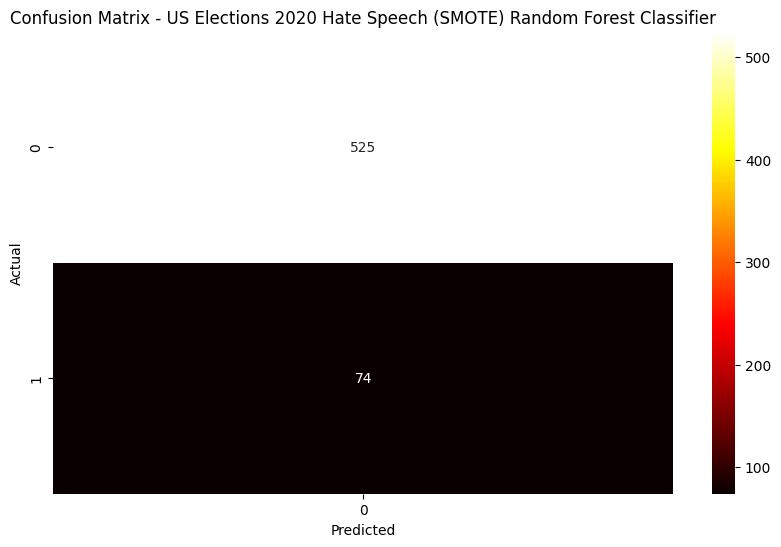

In [72]:
# Plot the confusion matrix using seaborn
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(us2020hs_y_test, us2020hs_rf_y_pred, rownames=['Actual'], colnames=['Predicted']), annot=True, fmt='d', cmap='hot')
plt.title(f'Confusion Matrix - US Elections 2020 Hate Speech ({balance}) Random Forest Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [73]:
# Generate a classification report for the Random Forest Classifier on the US Elections 2020 Hate Speech
us2020hs_rf_report = classification_report(us2020hs_y_test, us2020hs_rf_y_pred)
print("Classification Report for US Elections 2020 Hate Speech Random Forest Classifier:")
print(us2020hs_rf_report)

Classification Report for US Elections 2020 Hate Speech Random Forest Classifier:
              precision    recall  f1-score   support

           0       0.88      1.00      0.93       525
           1       0.00      0.00      0.00        74

    accuracy                           0.88       599
   macro avg       0.44      0.50      0.47       599
weighted avg       0.77      0.88      0.82       599



,feature,importance
1,Biden,0.534168
0,Trump,0.465832


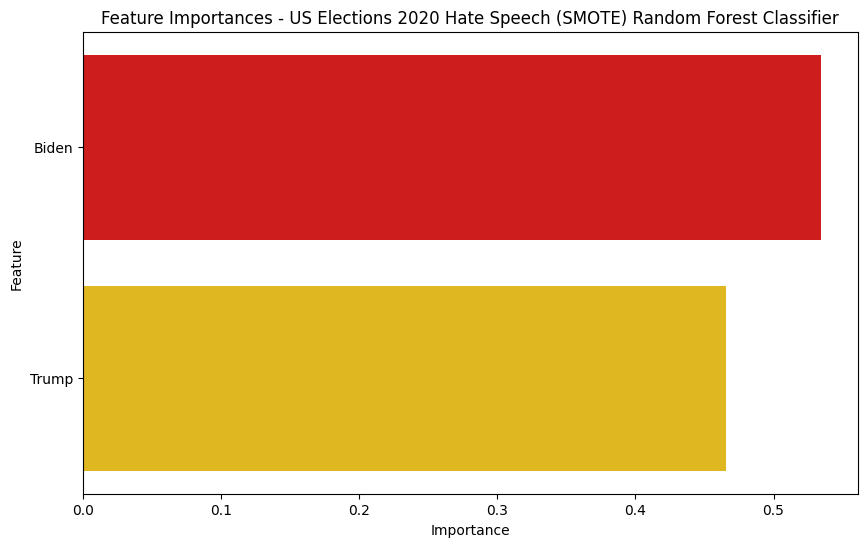

In [74]:
# Determine the feature importances
us2020hs_rf_feature_importances = us2020hs_rf_random_search.best_estimator_.named_steps['rf_classifier'].feature_importances_
us2020hs_rf_feature_importances_df = pd.DataFrame({'feature': us2020hs_X_train.columns, 'importance': us2020hs_rf_feature_importances}).sort_values('importance', ascending=False)
display(us2020hs_rf_feature_importances_df)

# Create a dictionary
us2020hs_rf_feature_importances_dict = us2020hs_rf_feature_importances_df.set_index('feature')['importance'].to_dict()

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=us2020hs_rf_feature_importances_df, palette='hot')
plt.title(f'Feature Importances - US Elections 2020 Hate Speech ({balance}) Random Forest Classifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [75]:
# Append details to the results list
rf_classification_results_list.append((
    "Random Forest",
    "US Elections 2020 Hate Speech",
    "NA",
    "NA",
    us2020hs_rf_accuracy,
    us2020hs_rf_f1,
    0.0,
    us2020hs_rf_random_search.best_params_,
    us2020hs_rf_feature_importances_dict
))

In [76]:
mlma_hate_speech_y_test.value_counts()

,count
target_groups,
1,2165
0,834
2,639
3,94


In [77]:
# Random Forest Classifier pipeline for mlma_hate_speech dataset
mlma_hate_speech_rf_pipeline = Pipeline([
    ('rf_classifier', RandomForestClassifier(random_state=42))
])

# Set the parameters for Randomized Search for Random Forest Classifier on the mlma_hate_speech dataset
mlma_hate_speech_rf_param_grid = {
    'rf_classifier__n_estimators': range(1000),
    'rf_classifier__max_depth': [mlma_hate_speech_sample_log2],
    'rf_classifier__min_samples_split': [mlma_hate_speech_sample_1_percent * i for i in range(2, 6)],
    'rf_classifier__min_samples_leaf': [mlma_hate_speech_sample_1_percent * i for i in range(1, 6)],
    'rf_classifier__criterion': ['gini', 'entropy']
}

In [78]:
start_time = time.time()
mlma_hate_speech_class_scorer = make_scorer(accuracy_score, greater_is_better=True)

mlma_hate_speech_rf_random_search = RandomizedSearchCV(mlma_hate_speech_rf_pipeline,
                                                   param_distributions=mlma_hate_speech_rf_param_grid,
                                                   n_iter=10,
                                                   cv=mlma_hate_speech_kf,
                                                   scoring=mlma_hate_speech_class_scorer,
                                                   random_state=42)
mlma_hate_speech_rf_random_search.fit(mlma_hate_speech_X_train_sample, mlma_hate_speech_y_train_sample)
end_time = time.time()
print("Best parameters for US Elections 2020 Hate Speech Random Forest Classifier:", mlma_hate_speech_rf_random_search.best_params_)
print("Best score for US Elections 2020 Hate Speech Random Forest Classifier:", mlma_hate_speech_rf_random_search.best_score_)
print("Time taken for US Elections 2020 Hate Speech Random Forest Classifier Randomized Search:", end_time - start_time)

Best parameters for US Elections 2020 Hate Speech Random Forest Classifier: {'rf_classifier__n_estimators': 685, 'rf_classifier__min_samples_split': 135, 'rf_classifier__min_samples_leaf': 45, 'rf_classifier__max_depth': 13, 'rf_classifier__criterion': 'gini'}
Best score for US Elections 2020 Hate Speech Random Forest Classifier: 0.6024990023942538
Time taken for US Elections 2020 Hate Speech Random Forest Classifier Randomized Search: 56.00593638420105


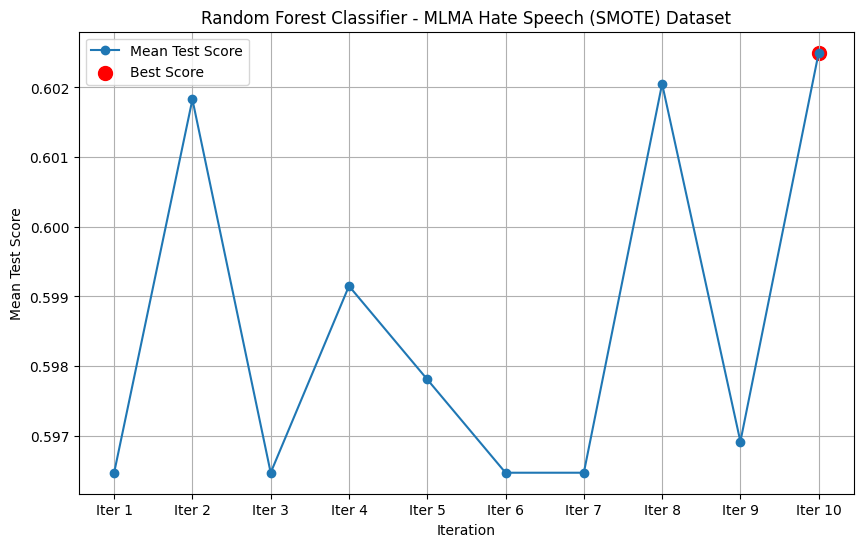

In [79]:
# Plot the accuracy scores for the Random Forest Classifier on the MLMA Hate Speech dataset for all iterations
plt.figure(figsize=(10, 6))
plt.plot(mlma_hate_speech_rf_random_search.cv_results_['mean_test_score'], marker='o', label='Mean Test Score')

# Plot the best score as a red x
mlma_hate_speech_rf_best_score_index = np.argmax(mlma_hate_speech_rf_random_search.cv_results_['mean_test_score'])
plt.scatter(mlma_hate_speech_rf_best_score_index, mlma_hate_speech_rf_random_search.cv_results_['mean_test_score'][mlma_hate_speech_rf_best_score_index], color='red', s=100, label='Best Score')

plt.title(f'Random Forest Classifier - MLMA Hate Speech ({balance}) Dataset')
plt.xlabel('Iteration')
plt.ylabel('Mean Test Score')
plt.xticks(range(len(mlma_hate_speech_rf_random_search.cv_results_['mean_test_score'])),
           [f"Iter {i+1}" for i in range(len(mlma_hate_speech_rf_random_search.cv_results_['mean_test_score']))])
plt.legend()
plt.grid()
plt.show()

In [80]:
# Predict on the test set
mlma_hate_speech_rf_y_pred = mlma_hate_speech_rf_random_search.predict(mlma_hate_speech_X_test)

In [81]:
# Evaluate the model
mlma_hate_speech_rf_accuracy = accuracy_score(mlma_hate_speech_y_test, mlma_hate_speech_rf_y_pred)
mlma_hate_speech_rf_f1 = f1_score(mlma_hate_speech_y_test, mlma_hate_speech_rf_y_pred, average='weighted')

print("MLMA Hate Speech Random Forest Classifier:")
print(f"Best Parameters: {mlma_hate_speech_rf_random_search.best_params_}")
print(f"Accuracy: {mlma_hate_speech_rf_accuracy:.4f}")
print(f"F1 Score: {mlma_hate_speech_rf_f1:.4f}")

MLMA Hate Speech Random Forest Classifier:
Best Parameters: {'rf_classifier__n_estimators': 685, 'rf_classifier__min_samples_split': 135, 'rf_classifier__min_samples_leaf': 45, 'rf_classifier__max_depth': 13, 'rf_classifier__criterion': 'gini'}
Accuracy: 0.6016
F1 Score: 0.5117


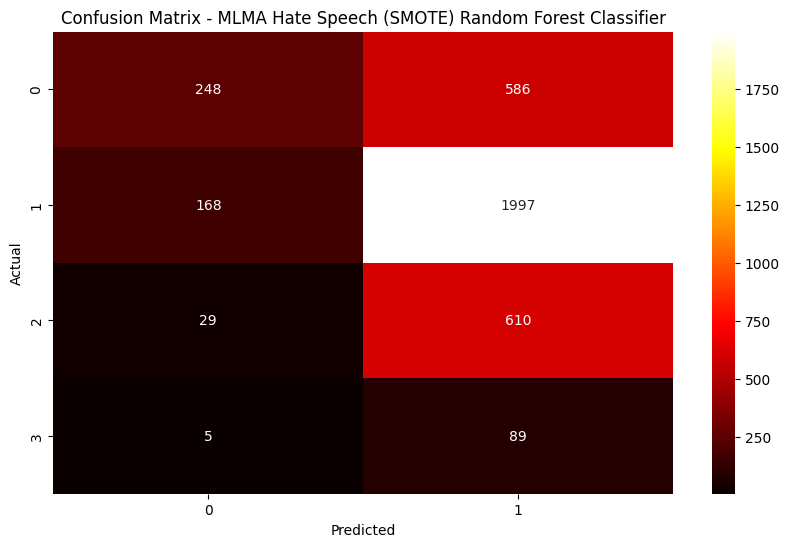

In [82]:
# Plot the confusion matrix using seaborn
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(mlma_hate_speech_y_test, mlma_hate_speech_rf_y_pred, rownames=['Actual'], colnames=['Predicted']), annot=True, fmt='d', cmap='hot')
plt.title(f'Confusion Matrix - MLMA Hate Speech ({balance}) Random Forest Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [83]:
# Generate a classification report for the Random Forest Classifier on the MLMA Hate Speech
mlma_hate_speech_rf_report = classification_report(mlma_hate_speech_y_test, mlma_hate_speech_rf_y_pred)
print("Classification Report for MLMA Hate Speech Random Forest Classifier:")
print(mlma_hate_speech_rf_report)

Classification Report for MLMA Hate Speech Random Forest Classifier:
              precision    recall  f1-score   support

           0       0.55      0.30      0.39       834
           1       0.61      0.92      0.73      2165
           2       0.00      0.00      0.00       639
           3       0.00      0.00      0.00        94

    accuracy                           0.60      3732
   macro avg       0.29      0.30      0.28      3732
weighted avg       0.48      0.60      0.51      3732



,feature,importance
2,annotator_sentiment,0.864168
3,abuse_level,0.051358
1,explicit,0.044398
0,implicit,0.040076


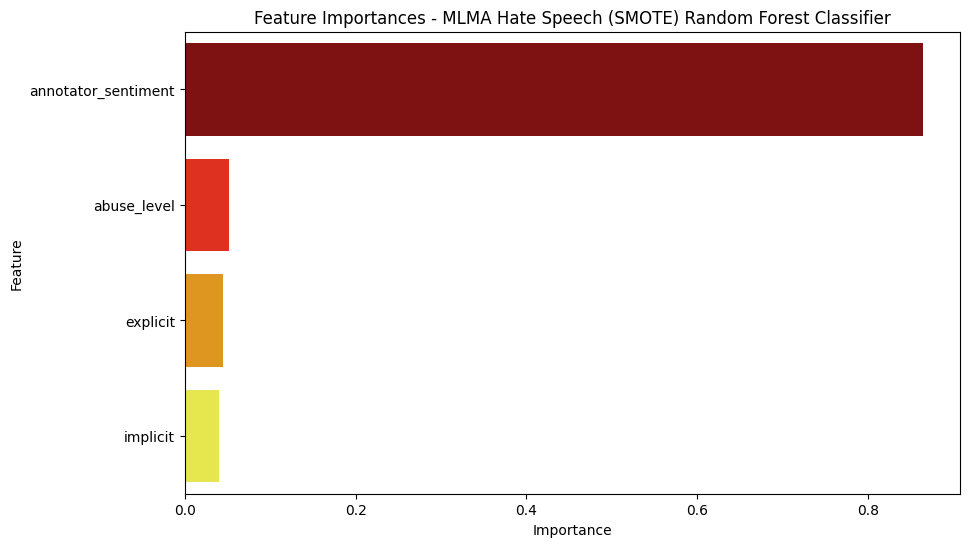

In [84]:
# Determine the feature importances
mlma_hate_speech_rf_feature_importances = mlma_hate_speech_rf_random_search.best_estimator_.named_steps['rf_classifier'].feature_importances_
mlma_hate_speech_rf_feature_importances_df = pd.DataFrame({'feature': mlma_hate_speech_X_train.columns, 'importance': mlma_hate_speech_rf_feature_importances}).sort_values('importance', ascending=False)
display(mlma_hate_speech_rf_feature_importances_df)

# Create a dictionary
mlma_hate_speech_rf_feature_importances_dict = mlma_hate_speech_rf_feature_importances_df.set_index('feature')['importance'].to_dict()

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=mlma_hate_speech_rf_feature_importances_df, palette='hot')
plt.title(f'Feature Importances - MLMA Hate Speech ({balance}) Random Forest Classifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [85]:
# Append details to the results list
rf_classification_results_list.append((
    "Random Forest",
    "MLMA Hate Speech",
    "NA",
    "NA",
    mlma_hate_speech_rf_accuracy,
    mlma_hate_speech_rf_f1,
    0.0,
    mlma_hate_speech_rf_random_search.best_params_,
    mlma_hate_speech_rf_feature_importances_dict
))

## Support Vector Machine Conclusions

In [86]:
# Convert the rf_classification_results_list to a DataFrame
rf_classification_summary = pd.DataFrame(rf_classification_results_list, columns=["Model", "Dataset", "Kernel", "Regularization", "Accuracy", "F1-score", "Ratio", "Best Parameters", "Feature Importances"])
rf_classification_summary["Balance"] = "SMOTE"
rf_classification_summary

,Model,Dataset,Kernel,Regularization,Accuracy,F1-score,Ratio,Best Parameters,Feature Importances,Balance
0,Random Forest,Convabuse,NA,NA,0.883545,0.849268,0.0,"{'rf_classifier__n_estimators': 958, 'rf_class...","{'system': 0.5232683880238173, 'explicit': 0.2...",SMOTE
1,Random Forest,Dynamically Generated Hate Speech,NA,NA,0.840498,0.840163,0.0,"{'rf_classifier__n_estimators': 958, 'rf_class...","{'type': 0.6583325371817896, 'target_groups': ...",SMOTE
2,Random Forest,Online Abusive Attacks,NA,NA,0.969762,0.968153,0.0,"{'rf_classifier__n_estimators': 958, 'rf_class...","{'Toxic parent tweets': 0.8162596519886234, 'T...",SMOTE
3,Random Forest,US Elections 2020 Hate Speech,NA,NA,0.876461,0.818758,0.0,"{'rf_classifier__n_estimators': 795, 'rf_class...","{'Biden': 0.5341675069108166, 'Trump': 0.46583...",SMOTE
4,Random Forest,MLMA Hate Speech,NA,NA,0.601554,0.511696,0.0,"{'rf_classifier__n_estimators': 685, 'rf_class...","{'annotator_sentiment': 0.8641681954671636, 'a...",SMOTE


In [87]:
output_path = '/content/drive/My Drive/Online MSDS/MOD C2/Political Polarization/results/'
rf_classification_summary.to_csv(f"{output_path}/model6_rf-classification-summary_SMOTE.csv", index=False)